# MSG-RM (Reissner-Mindlin) Based Timoshenko Beam

The **Reissner–Mindlin (RM) shell** cross-section model carries an independent through-thickness director
rotation, so it keeps the **transverse-shear** compliance that the Kirchhoff–Love (KL) model drops. This
tutorial runs the RM solver on the **anisotropic two-cell $[-45]$ tube** (a single $[-45]$ ply, $R/h = 12.5$,
taken at the **wall-centre reference**) directly from its 1-D shell SG YAML, and — to justify what RM buys —
also runs the **KL** shell, benchmarking both against the 2-D solid.

The Timoshenko beam stiffness is a $6\times6$ whose rows/columns mean
**1 = extension, 2–3 = transverse shear, 4 = torsion, 5–6 = bending** — the same ordering as a VABS `.K` file.

> RM driver: `strip_RM.rm_timoshenko_6x6(yaml, frac, dshift, curved, shear="mitc")`.

In [1]:
import os, sys
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for p in (CC, os.path.join(CC, "opensg_jax")):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=150, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
from opensg_jax.fe_jax.timo_report import (sym, pcterr, full_pcterr, diag_table, term_table,
                                          compare_terms, print_6x6, nonzero_terms, parse_vabs, wall_t, LBL)
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
print("environment ready  |  jax", jax.__version__)

environment ready  |  jax 0.9.2


In [2]:
SHELL = os.path.join(CC, "examples", "data", "1d_yaml", "tube2cell_m45_shell.yaml")
SOLIDY = os.path.join(CC, "examples", "data", "2d_yaml", "tube2cell_m45_solid.yaml")
BENCH = os.path.join(CC, "examples", "data", "benchmark", "tube2cell_m45_solid_ref.txt")   # 2-D solid reference 6x6
T = wall_t(SHELL)                                              # wall thickness (sum of ply thicknesses)
print("two-cell [-45] tube  |  wall thickness t = %.4f m,  R/h = %.1f  (thin wall)" % (T, 0.05 / T))

two-cell [-45] tube  |  wall thickness t = 0.0040 m,  R/h = 12.5  (thin wall)

## 1 · Cross-section: geometry & reference

The 2-D solid mesh of the two-cell tube (a circular $[-45]$ wall split by a diametral shear web). The dashed
red line is the **wall-centre reference** at radius $R$ — the surface at which the 1-D shell ABD is taken
(`dshift = t/2`), so the shell and solid share the same beam reference axis.

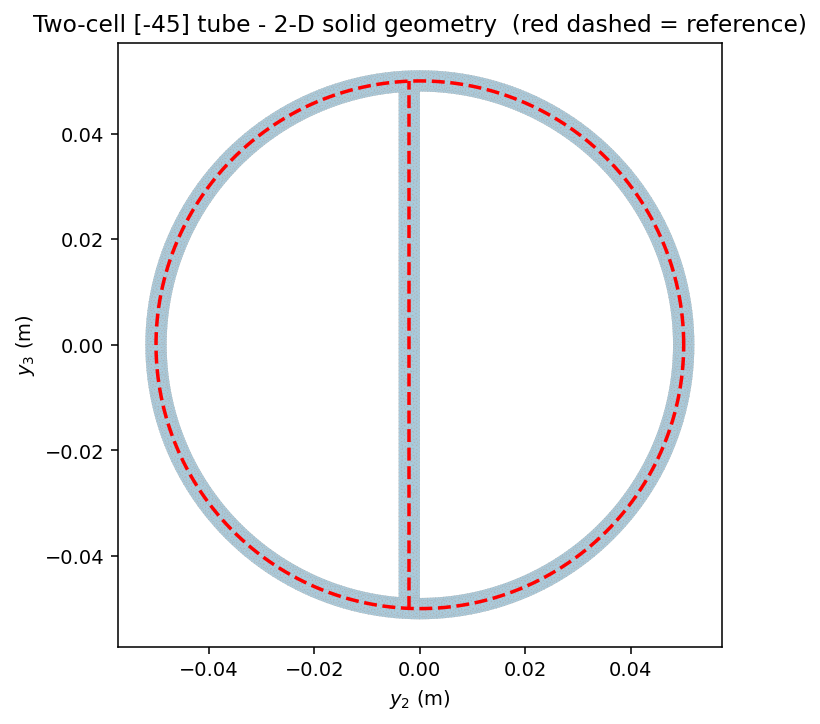

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from opensg_jax.fe_jax.segment import read_solid_yaml
sg = read_solid_yaml(SOLIDY)
nd, cells, dom, mp = sg["points"], sg["cells"], sg["cell_domain_ids"], sg["material_param"]
uniq, inv = np.unique(mp[dom], axis=0, return_inverse=True)      # same material/layup -> same colour
palette = ["#a6cee3", "#fdbf6f", "#b2df8a", "#fb9a99", "#cab2d6", "#ffff99"]
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.add_collection(PolyCollection([nd[c] for c in cells], facecolors=[palette[i % len(palette)] for i in inv],
                                 edgecolors="0.6", linewidths=0.08))
ax.autoscale_view()
cent = np.array([nd[c].mean(0) for c in cells])
web_xc = cent[np.hypot(cent[:, 0], cent[:, 1]) < 0.046, 0].mean()   # web centre (the web sits inside the ring)
th = np.linspace(0, 2 * np.pi, 240)
ax.plot(0.05 * np.cos(th), 0.05 * np.sin(th), "r--", lw=1.8)        # wall-centre reference
ax.plot([web_xc, web_xc], [-0.05, 0.05], "r--", lw=1.8)            # web-centre reference
ax.set_aspect("equal"); ax.set_title("Two-cell [-45] tube - 2-D solid geometry  (red dashed = reference)")
ax.set_xlabel(r"$y_2$ (m)"); ax.set_ylabel(r"$y_3$ (m)")
png = os.path.join(CC, "docs", "tutorials", "_img", "twocell_geom_ref.png")
fig.savefig(png, dpi=140, bbox_inches="tight"); plt.close(fig)
Image(filename=png)

## 2 · Material orientation

Per-element material axes on the shell and solid meshes: **$e_2$ (blue)** is the in-plane ply direction and
**$e_3$ (green)** is the wall normal.

[orient_plot] wrote _img/twocell_rm_orient.png


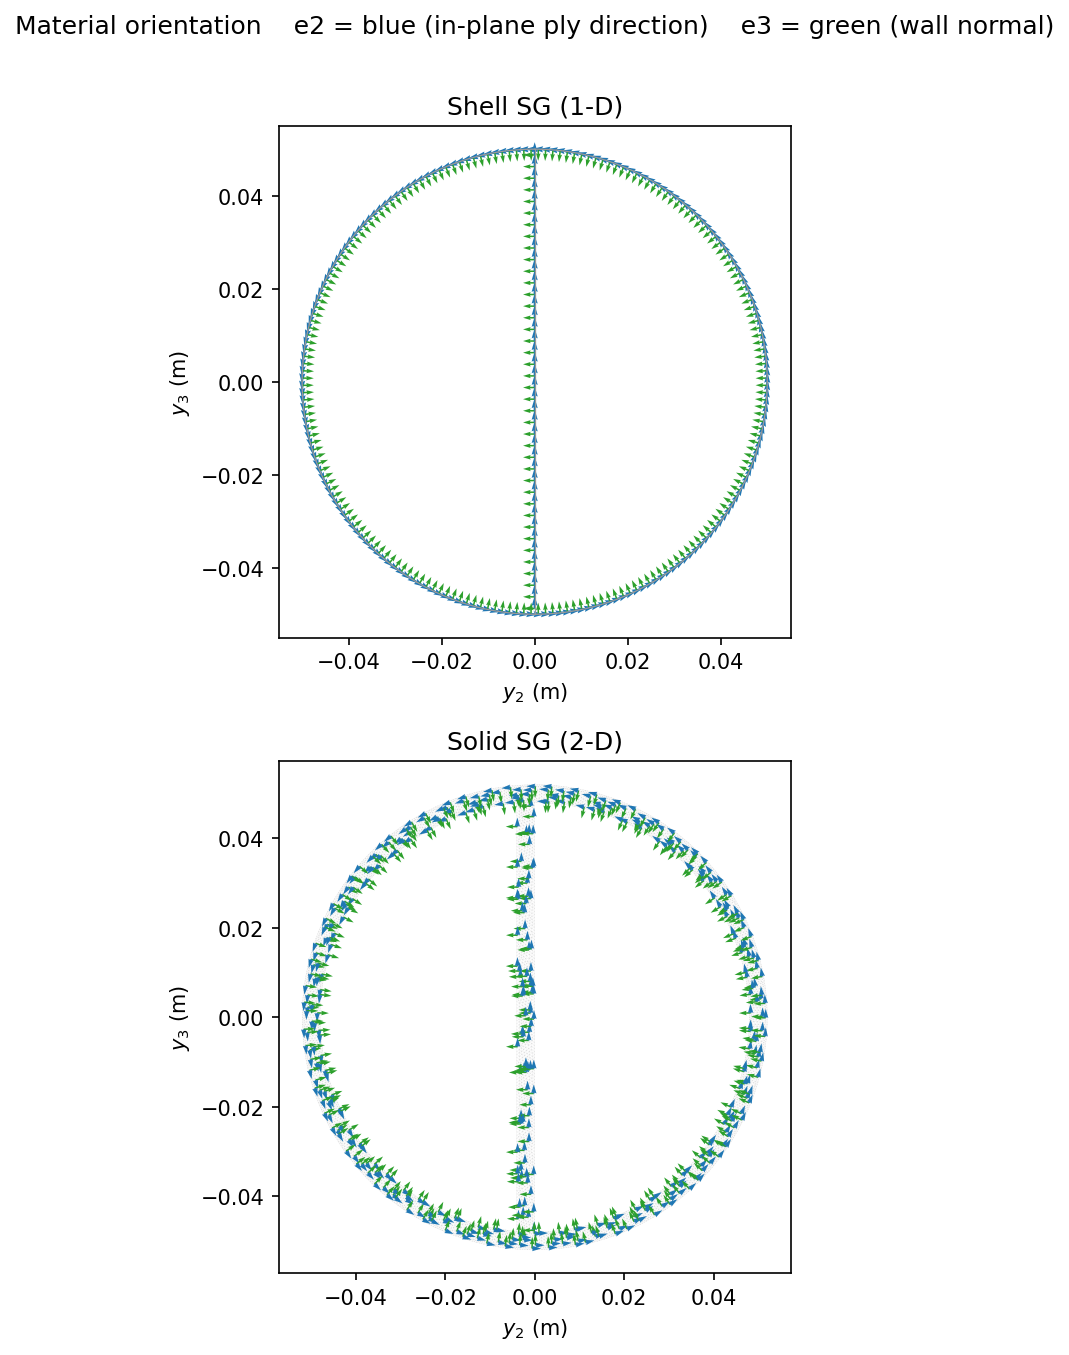

In [4]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(CC, "docs", "tutorials", "_img", "twocell_rm_orient.png"))
Image(filename=png)

## 3 · Compute the MSG-RM

The RM solve at the wall-centre reference (`frac=0.0`, `dshift=t/2`, curved wall, MITC transverse shear):

In [5]:
C_rm = sym(rm_timoshenko_6x6(SHELL, 0.0, dshift=T / 2, curved=True, shear="mitc", orient=False))
print("RM: Timoshenko beam stiffness:")
print(C_rm)

RM: Timoshenko beam stiffness:
[[20210148.7738       -0.1028 -1223175.3495  -210883.5897       -0.0024     -391.4396]
 [      -0.1028  4437983.2299        0.6154       -0.       104005.1206        0.0087]
 [-1223175.3495        0.6154  7323760.8033     -435.0868        0.0144   103686.4707]
 [ -210883.5897       -0.         -435.0868    23494.4875       -0.            3.4489]
 [      -0.0024   104005.1206        0.0144       -0.        22866.2538        0.0002]
 [    -391.4396        0.0087   103686.4707        3.4489        0.0002    19175.9887]]


## 4 · Kirchhoff–Love (KL) for comparison

KL uses Hermite-$C^1$ kinematics with **no** independent shear director, so it cannot carry transverse shear.
Running it on the *same* section makes the comparison below meaningful — it shows exactly which terms RM recovers.

In [6]:
C_kl = sym(gradient_junction_kirchhoff(SHELL, frac=0.0, dshift=T / 2)[0])
print("KL: Timoshenko beam stiffness:")
print(C_kl)

[orient_plot] wrote ../../examples/data/1d_yaml/tube2cell_m45_shell_orient_e1e2e3.png


KL: Timoshenko beam stiffness:
[[20197348.2049     8752.6978 -1106931.4649  -210811.6003      250.7302     1189.7842]
 [    8752.6978  3868949.5758   -10591.3894    -1202.3015    90919.655     -1120.8088]
 [-1106931.4649   -10591.3894  6513516.663      -141.8618     -594.7187    92716.7175]
 [ -210811.6003    -1202.3015     -141.8618    23476.1413      -27.9385        7.3336]
 [     250.7302    90919.655      -594.7187      -27.9385    22562.894       -31.7231]
 [    1189.7842    -1120.8088    92716.7175        7.3336      -31.7231    19029.1006]]


## 5 · RM vs KL vs the 2-D solid

On the $[-45]$ tube the **transverse-shear terms separate the models**: the shear block $C_{22},C_{33}$ (and
their couplings) is where KL is off by ~10–15 % while RM stays within a couple of percent of the solid.

In [7]:
S = sym(np.loadtxt(BENCH))                                    # 2-D solid reference
print("RM and KL vs the 2-D solid - every non-zero Cij term:")
compare_terms(S, {"RM": C_rm, "KL": C_kl})

RM and KL vs the 2-D solid - every non-zero Cij term:
  term             solid/ref             RM      RM%d             KL      KL%d
  C11(EA)         2.0008e+07     2.0210e+07    +1.01     2.0197e+07    +0.95
  C13            -1.1976e+06    -1.2232e+06    +2.13    -1.1069e+06    -7.57
  C14            -2.0915e+05    -2.1088e+05    +0.83    -2.1081e+05    +0.79
  C22(GA2)        4.4880e+06     4.4380e+06    -1.11     3.8689e+06   -13.79
  C25             1.0449e+05     1.0401e+05    -0.46     9.0920e+04   -12.99
  C33(GA3)        7.3348e+06     7.3238e+06    -0.15     6.5135e+06   -11.20
  C36             1.0126e+05     1.0369e+05    +2.40     9.2717e+04    -8.43
  C44(GJ)         2.3570e+04     2.3494e+04    -0.32     2.3476e+04    -0.40
  C55(EI2)        2.2482e+04     2.2866e+04    +1.71     2.2563e+04    +0.36


## Takeaway

Both shells agree with the 2-D solid on extension, torsion and bending; only the **transverse-shear** terms
distinguish them, and that is precisely what the RM director recovers. For this thin-walled two-cell section
the RM shell reproduces the full $6\times6$ of the much more expensive 2-D solid. See
{doc}`twocell_m45_asc` for how the gap grows with wall thickness ($R/h$).